## Load library and file

In [8]:
# Upgrade nilearn and numpy to fix ImportError

# Plot the heatmap of the top regions on a brain surface using nilearn
import numpy as np
import pandas as pd
from nilearn import plotting, datasets
import matplotlib.pyplot as plt
import os

shap_dir = "shap_gcn_results_QSM_grad"
save_dir = "../../SHAP_figures/MD+thickness+QSM"
# Load SHAP of one fold and repeat
shap_values = np.load(os.path.join(shap_dir, "shap_fold1_rep1.npy"))
# Show the data shape
print("SHAP values shape:", shap_values.shape)

SHAP values shape: (9, 2924)


In [9]:
# Load the shap of all 7 folds and 10 reps
shap_values = []
mean_abs_md_shap_values_per_model = []
mean_abs_qsm_shap_values_per_model = []
mean_std_md_shap_values_per_model = []
mean_std_qsm_shap_values_per_model = []
mean_abs_md_shap_values_per_subject = []
mean_std_md_shap_values_per_subject = []
mean_abs_qsm_shap_values_per_subject = []
mean_std_qsm_shap_values_per_subject = []

md_feat_dim = 22
qsm_feat_dim = 21
n_nodes = 68
n_feat = md_feat_dim + qsm_feat_dim
md_len = md_feat_dim * n_nodes
qsm_len = qsm_feat_dim * n_nodes

for fold in range(1, 8):
    for rep in range(1, 11):

        shap_for_model = np.abs(np.load(os.path.join(shap_dir, f"shap_fold{fold}_rep{rep}.npy")))
        # Calculate mean absolute SHAP values for this model and std
        mean_abs_md_shap_for_model = np.mean(shap_for_model, axis=0)[:md_len].reshape(n_nodes, md_feat_dim)
        mean_abs_md_shap_values_per_model.append(mean_abs_md_shap_for_model)
        mean_abs_qsm_shap_for_model = np.mean(shap_for_model, axis=0)[md_len:].reshape(n_nodes, qsm_feat_dim)
        mean_abs_qsm_shap_values_per_model.append(mean_abs_qsm_shap_for_model)
        mean_std_md_shap_for_model = np.std(shap_for_model, axis=0)[:md_len].reshape(n_nodes, md_feat_dim)
        mean_std_md_shap_values_per_model.append(mean_std_md_shap_for_model)
        mean_std_qsm_shap_for_model = np.std(shap_for_model, axis=0)[md_len:].reshape(n_nodes, qsm_feat_dim)
        mean_std_qsm_shap_values_per_model.append(mean_std_qsm_shap_for_model)

        shap_values.extend(shap_for_model)

print("SHAP values length:", len(shap_values))
if len(shap_values) > 0:
    print("Shape of one element in shap_values:", np.array(shap_values[0]).shape)

mean_std_md_shap_values_per_model = np.std(mean_abs_md_shap_values_per_model, axis=0)
mean_abs_md_shap_values_per_model = np.mean(mean_abs_md_shap_values_per_model, axis=0)
mean_abs_md_shap_values_per_subject = np.mean(shap_values, axis=0)[:md_len].reshape(n_nodes, md_feat_dim)
mean_std_md_shap_values_per_subject = np.std(shap_values, axis=0)[:md_len].reshape(n_nodes, md_feat_dim)

mean_std_qsm_shap_values_per_model = np.std(mean_abs_qsm_shap_values_per_model, axis=0)
mean_abs_qsm_shap_values_per_model = np.mean(mean_abs_qsm_shap_values_per_model, axis=0)
mean_abs_qsm_shap_values_per_subject = np.mean(shap_values, axis=0)[md_len:].reshape(n_nodes, qsm_feat_dim)
mean_std_qsm_shap_values_per_subject = np.std(shap_values, axis=0)[md_len:].reshape(n_nodes, qsm_feat_dim)

SHAP values length: 590
Shape of one element in shap_values: (2924,)


## Region keys

In [10]:
# List of hemispheres
HEMIS = ["lh", "rh"]
REGION_NAMES = ['bankssts',
'caudalanteriorcingulate',
'caudalmiddlefrontal',
'cuneus',
'entorhinal',
'fusiform',
'inferiorparietal',
'inferiortemporal',
'isthmuscingulate',
'lateraloccipital',
'lateralorbitofrontal',
'lingual',
'medialorbitofrontal',
'middletemporal',
'parahippocampal',
'paracentral',
'parsopercularis',
'parsorbitalis',
'parstriangularis',
'pericalcarine',
'postcentral',
'posteriorcingulate',
'precentral',
'precuneus',
'rostralanteriorcingulate',
'rostralmiddlefrontal',
'superiorfrontal',
'superiorparietal',
'superiortemporal',
'supramarginal',
'frontalpole',
'temporalpole',
'transversetemporal',
'insula'
]
region_keys = [f"{hemi}_{region}" for hemi in HEMIS for region in REGION_NAMES]

# Feature names
MD_FEATURE_NAMES = ['MD Depth 1', 'MD Depth 2', 'MD Depth 3', 'MD Depth 4', 'MD Depth 5', 'MD Depth 6', 'MD Depth 7', 'MD Depth 8', 'MD Depth 9', 'MD Depth 10',
                 'MD Depth 11', 'MD Depth 12', 'MD Depth 13', 'MD Depth 14', 'MD Depth 15', 'MD Depth 16', 'MD Depth 17', 'MD Depth 18', 'MD Depth 19', 'MD Depth 20', 'MD Depth 21',
                'Mean Thickness']
QSM_FEATURE_NAMES = ['QSM Depth 1', 'QSM Depth 2', 'QSM Depth 3', 'QSM Depth 4', 'QSM Depth 5', 'QSM Depth 6', 'QSM Depth 7', 'QSM Depth 8', 'QSM Depth 9', 'QSM Depth 10',
                 'QSM Depth 11', 'QSM Depth 12', 'QSM Depth 13', 'QSM Depth 14', 'QSM Depth 15', 'QSM Depth 16', 'QSM Depth 17', 'QSM Depth 18', 'QSM Depth 19', 'QSM Depth 20', 'QSM Depth 21']
FEATURE_NAMES = MD_FEATURE_NAMES + QSM_FEATURE_NAMES

## Plot SHAP of MD

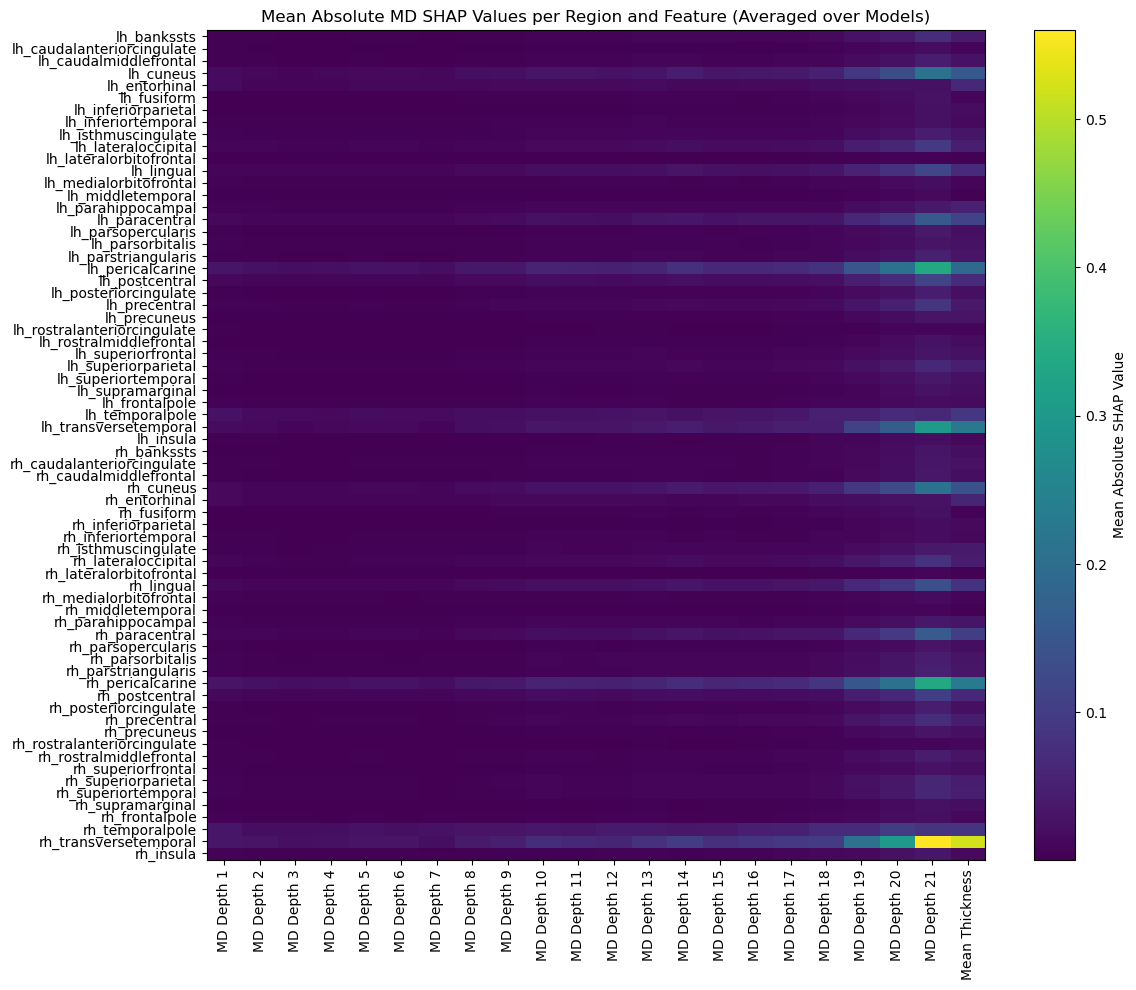

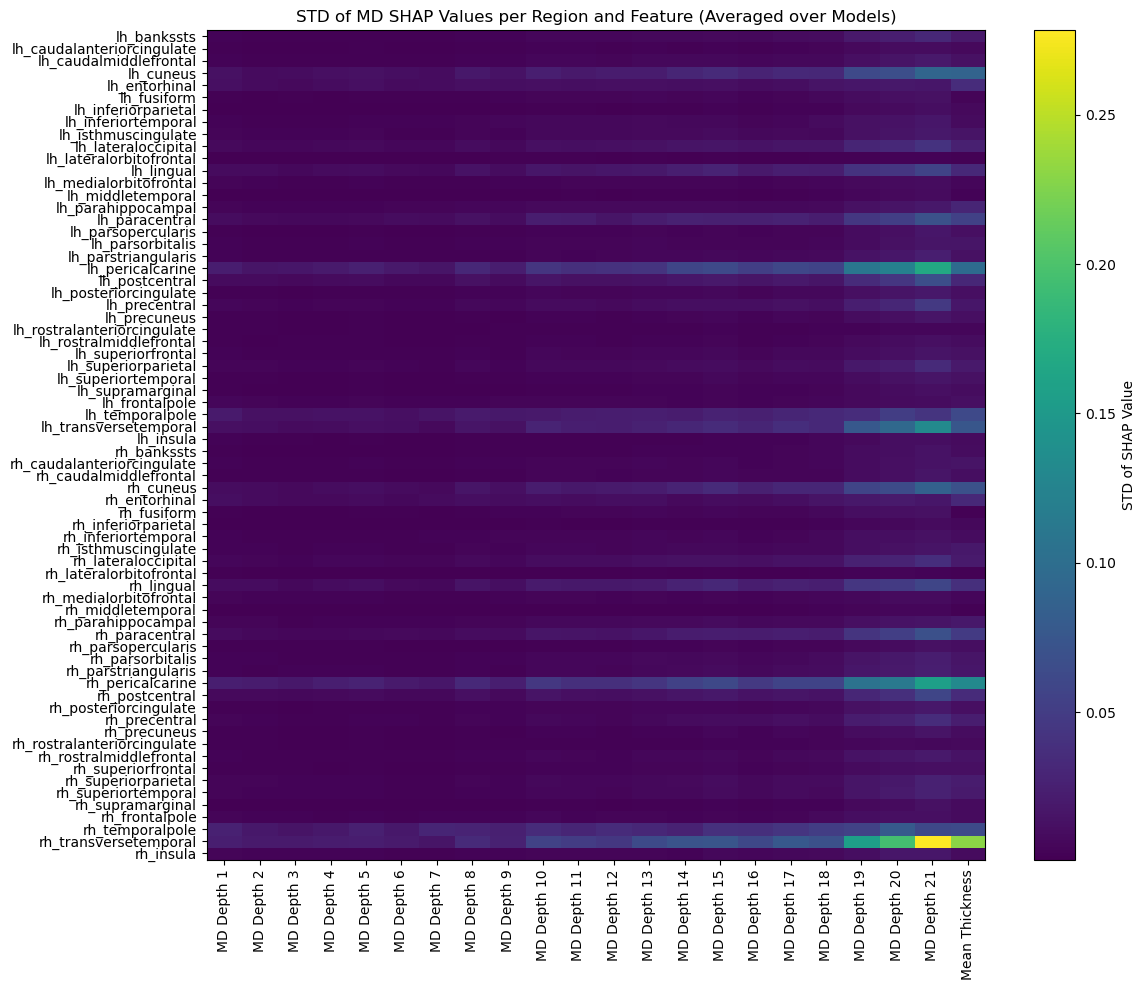

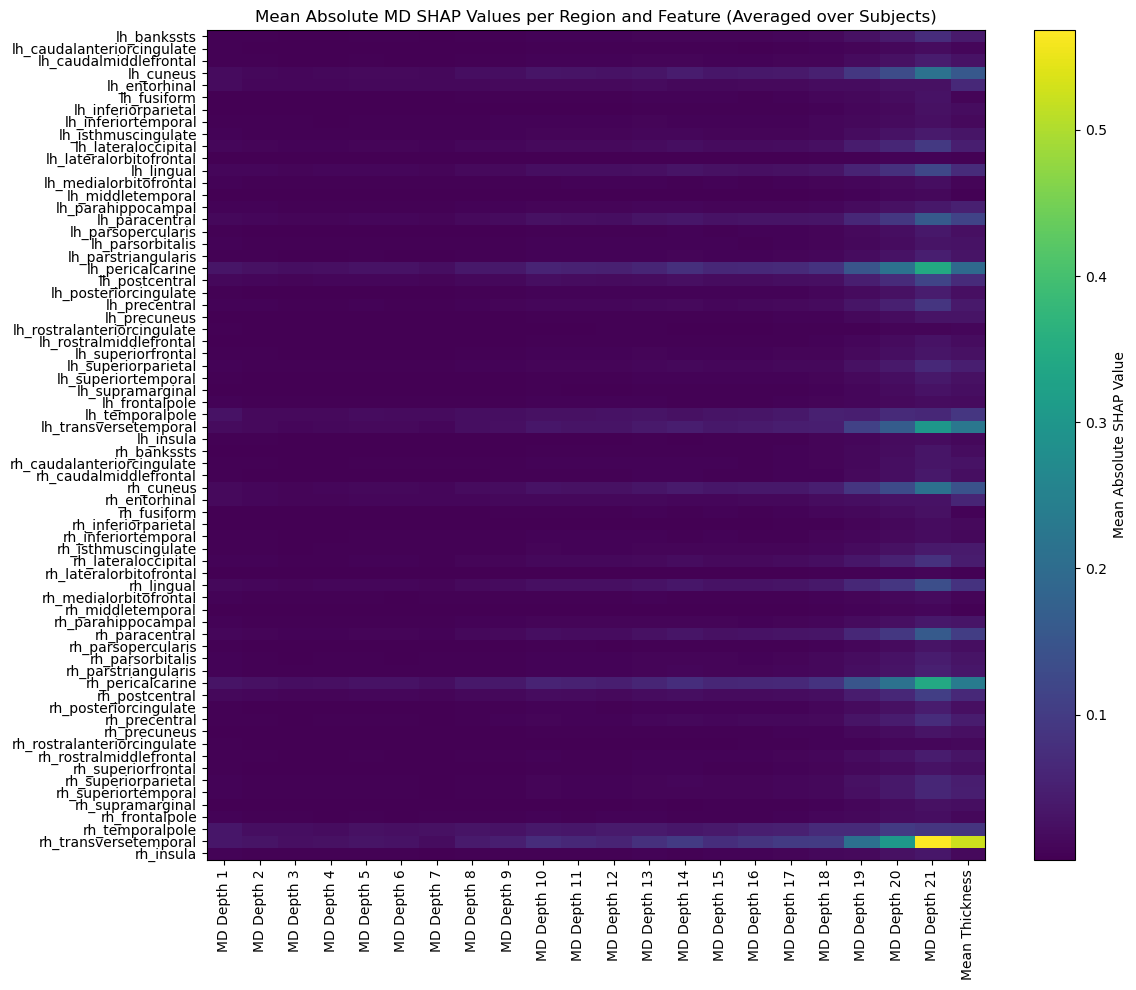

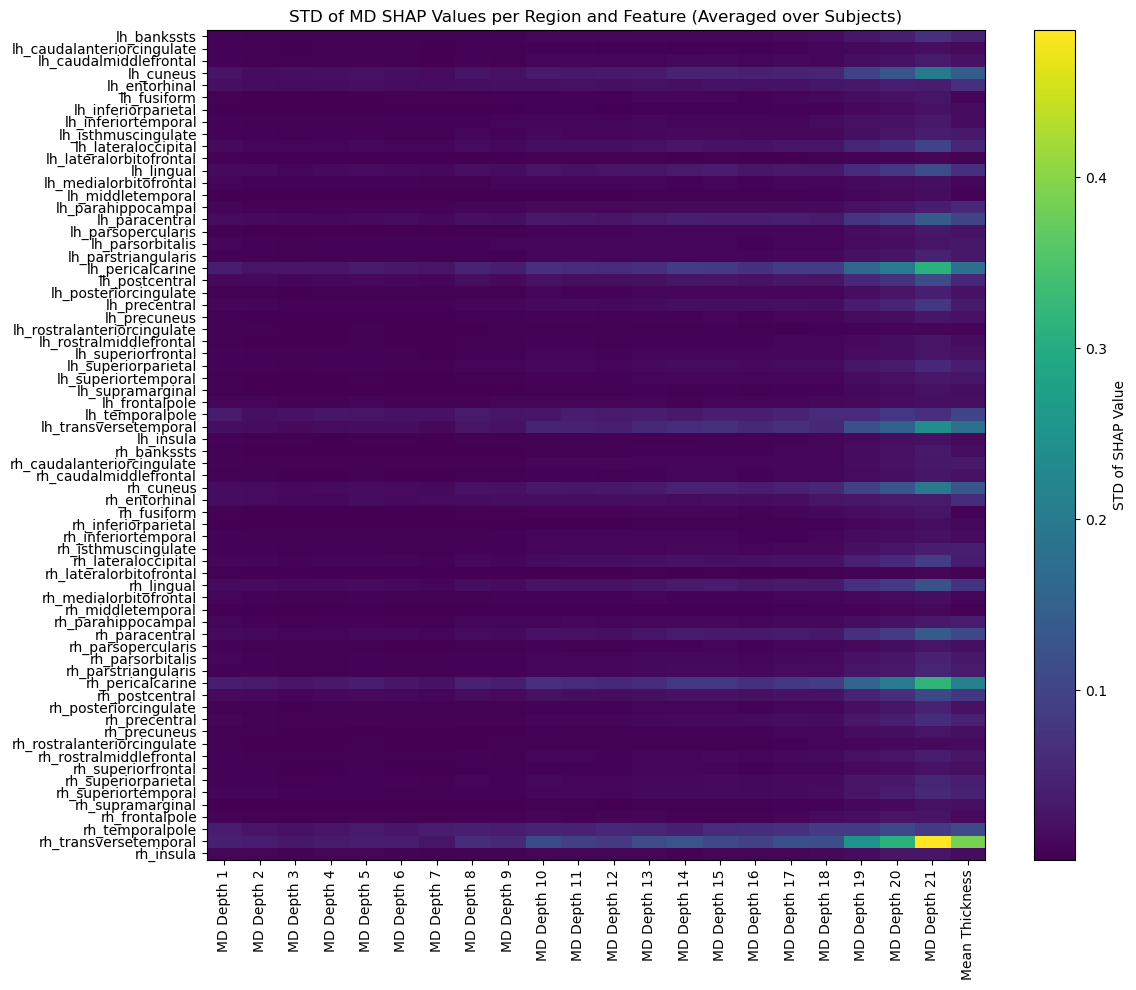

In [11]:
# Display the heatmap of mean absolute SHAP values for each region and feature
# Plot the heatmap of mean absolute SHAP values for each region and feature per model
plt.figure(figsize=(12, 10))
plt.imshow(mean_abs_md_shap_values_per_model, aspect='auto', cmap='viridis')
plt.colorbar(label='Mean Absolute SHAP Value')
plt.xticks(ticks=np.arange(len(MD_FEATURE_NAMES)), labels=MD_FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(region_keys)), labels=region_keys)
plt.title('Mean Absolute MD SHAP Values per Region and Feature (Averaged over Models)')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "md_mean_abs_shap_per_model_heatmap.png"))
plt.show()

# Plot the heatmap of std SHAP values for each region and feature per model
plt.figure(figsize=(12, 10))
plt.imshow(mean_std_md_shap_values_per_model, aspect='auto', cmap='viridis')
plt.colorbar(label='STD of SHAP Value')
plt.xticks(ticks=np.arange(len(MD_FEATURE_NAMES)), labels=MD_FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(region_keys)), labels=region_keys)
plt.title('STD of MD SHAP Values per Region and Feature (Averaged over Models)')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "md_std_shap_per_model_heatmap.png"))
plt.show()

# Plot the heatmap of mean absolute SHAP values for each region and feature per subject
plt.figure(figsize=(12, 10))
plt.imshow(mean_abs_md_shap_values_per_subject, aspect='auto', cmap='viridis')
plt.colorbar(label='Mean Absolute SHAP Value')
plt.xticks(ticks=np.arange(len(MD_FEATURE_NAMES)), labels=MD_FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(region_keys)), labels=region_keys)
plt.title('Mean Absolute MD SHAP Values per Region and Feature (Averaged over Subjects)')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "md_mean_abs_shap_per_subject_heatmap.png"))
plt.show()

# Plot the heatmap of std SHAP values for each region and feature per subject
plt.figure(figsize=(12, 10))
plt.imshow(mean_std_md_shap_values_per_subject, aspect='auto', cmap='viridis')
plt.colorbar(label='STD of SHAP Value')
plt.xticks(ticks=np.arange(len(MD_FEATURE_NAMES)), labels=MD_FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(region_keys)), labels=region_keys)
plt.title('STD of MD SHAP Values per Region and Feature (Averaged over Subjects)')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "md_std_shap_per_subject_heatmap.png"))
plt.show()


## Plot SHAP of QSM

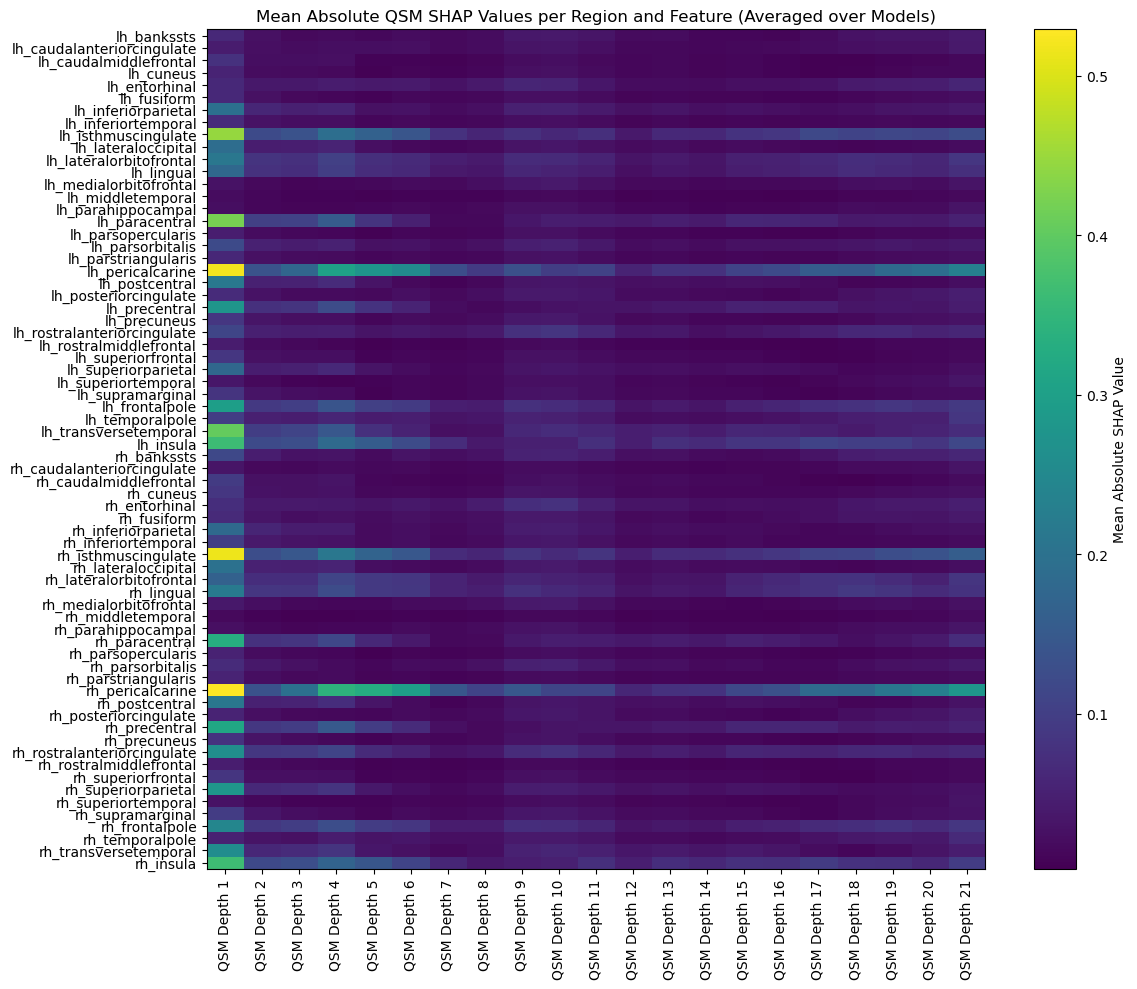

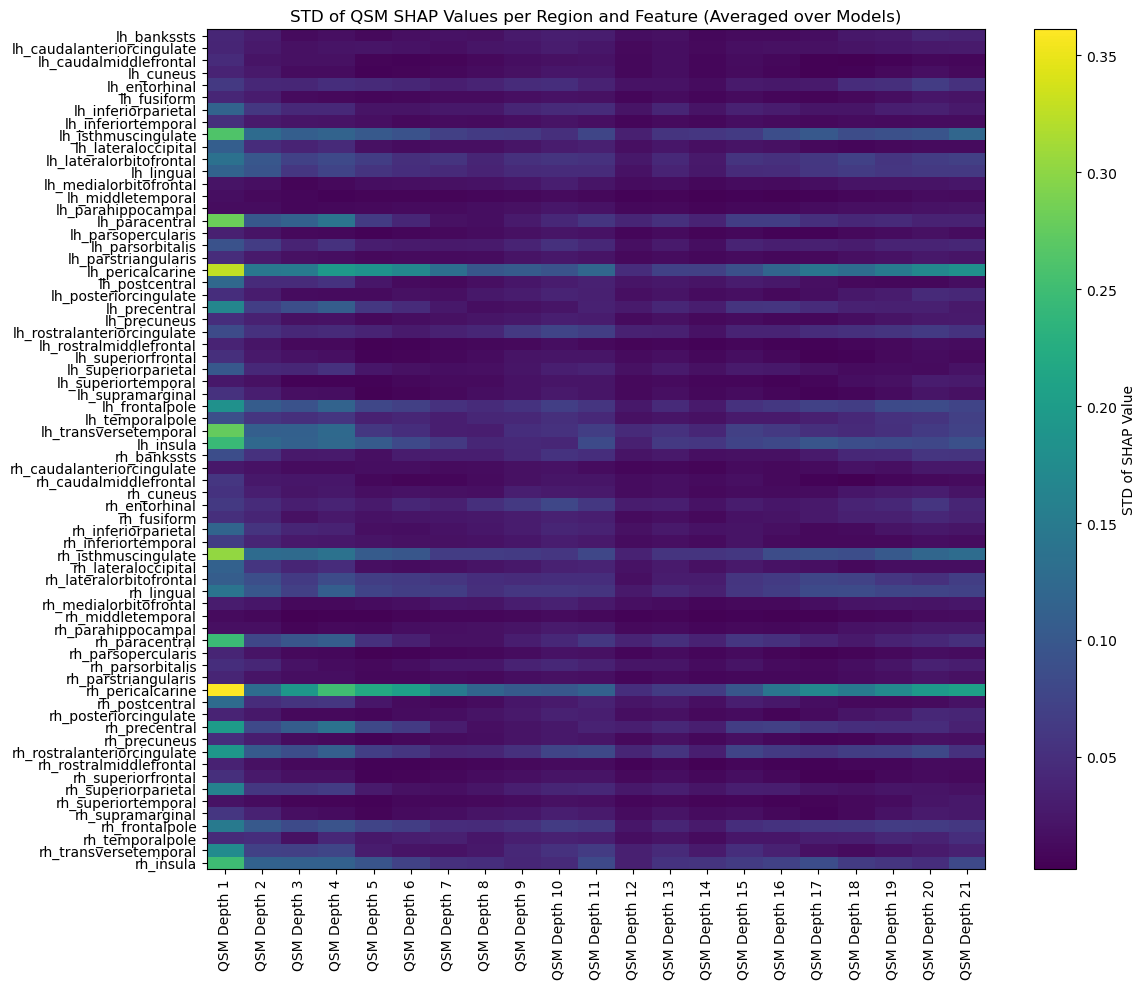

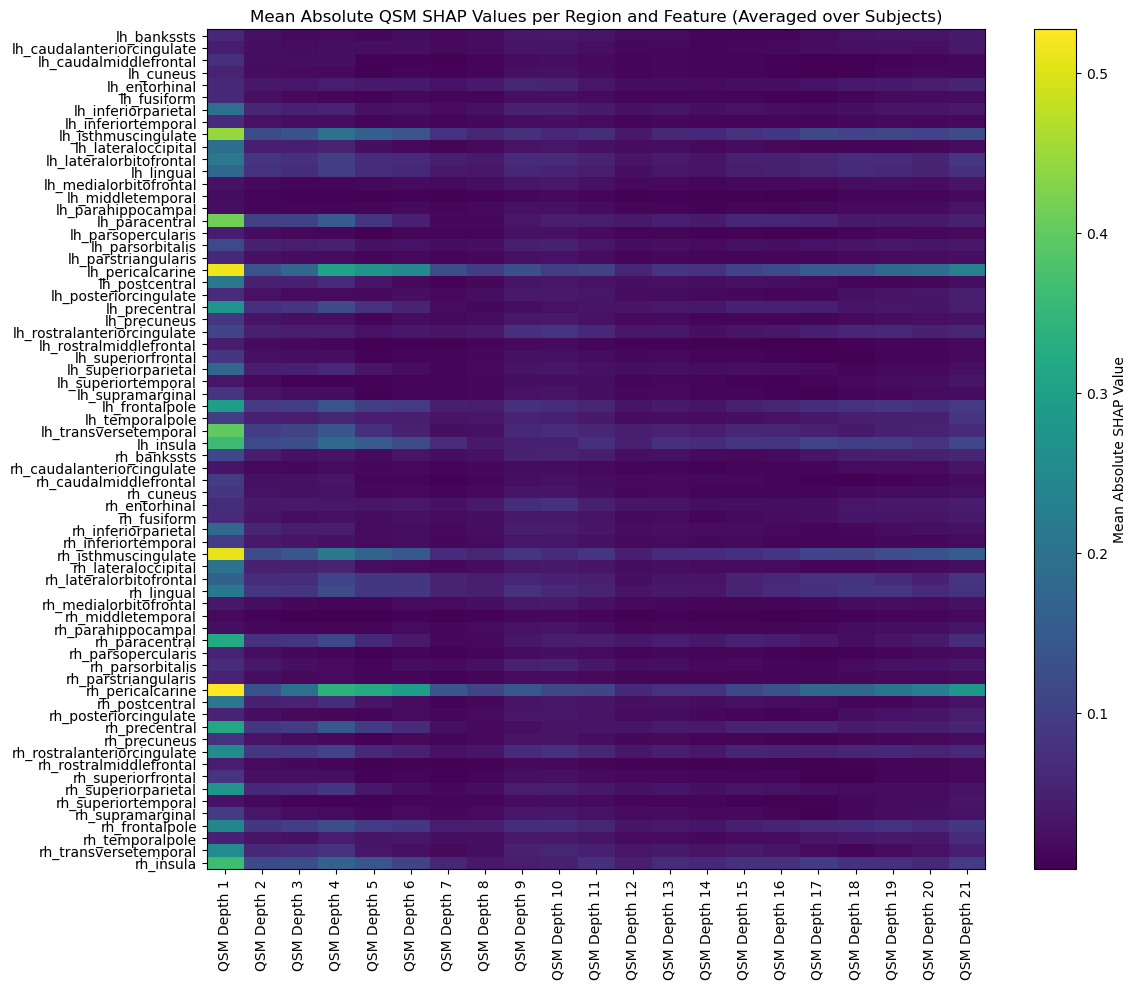

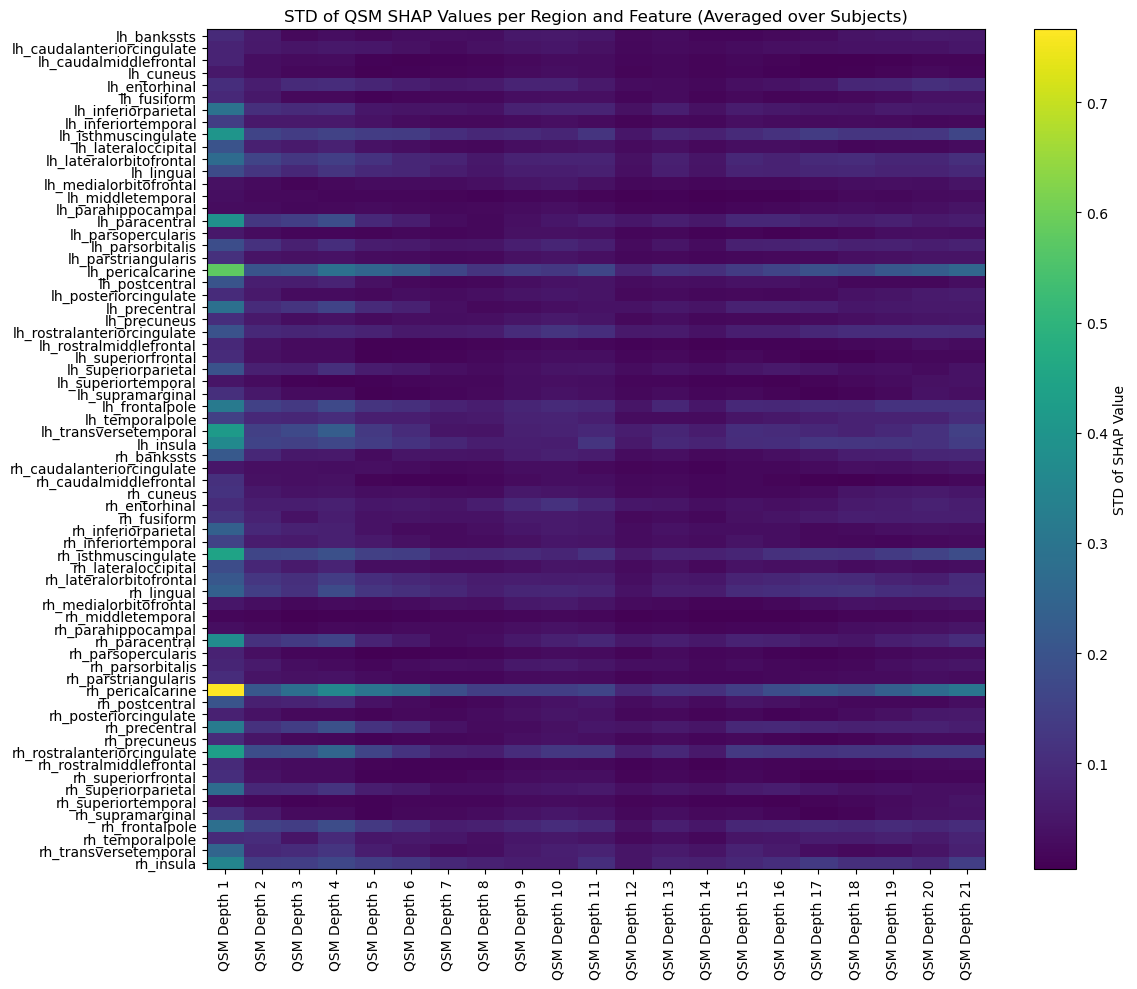

In [12]:
# Display the heatmap of mean absolute SHAP values for each region and feature
# Plot the heatmap of mean absolute SHAP values for each region and feature per model
plt.figure(figsize=(12, 10))
plt.imshow(mean_abs_qsm_shap_values_per_model, aspect='auto', cmap='viridis')
plt.colorbar(label='Mean Absolute SHAP Value')
plt.xticks(ticks=np.arange(len(QSM_FEATURE_NAMES)), labels=QSM_FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(region_keys)), labels=region_keys)
plt.title('Mean Absolute QSM SHAP Values per Region and Feature (Averaged over Models)')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "qsm_mean_abs_shap_per_model_heatmap.png"))
plt.show()

# Plot the heatmap of std SHAP values for each region and feature per model
plt.figure(figsize=(12, 10))
plt.imshow(mean_std_qsm_shap_values_per_model, aspect='auto', cmap='viridis')
plt.colorbar(label='STD of SHAP Value')
plt.xticks(ticks=np.arange(len(QSM_FEATURE_NAMES)), labels=QSM_FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(region_keys)), labels=region_keys)
plt.title('STD of QSM SHAP Values per Region and Feature (Averaged over Models)')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "qsm_std_shap_per_model_heatmap.png"))
plt.show()

# Plot the heatmap of mean absolute SHAP values for each region and feature per subject
plt.figure(figsize=(12, 10))
plt.imshow(mean_abs_qsm_shap_values_per_subject, aspect='auto', cmap='viridis')
plt.colorbar(label='Mean Absolute SHAP Value')
plt.xticks(ticks=np.arange(len(QSM_FEATURE_NAMES)), labels=QSM_FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(region_keys)), labels=region_keys)
plt.title('Mean Absolute QSM SHAP Values per Region and Feature (Averaged over Subjects)')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "qsm_mean_abs_shap_per_subject_heatmap.png"))
plt.show()

# Plot the heatmap of std SHAP values for each region and feature per subject
plt.figure(figsize=(12, 10))
plt.imshow(mean_std_qsm_shap_values_per_subject, aspect='auto', cmap='viridis')
plt.colorbar(label='STD of SHAP Value')
plt.xticks(ticks=np.arange(len(QSM_FEATURE_NAMES)), labels=QSM_FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(region_keys)), labels=region_keys)
plt.title('STD of QSM SHAP Values per Region and Feature (Averaged over Subjects)')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "qsm_std_shap_per_subject_heatmap.png"))
plt.show()


## Plot SHAP of TOP MD

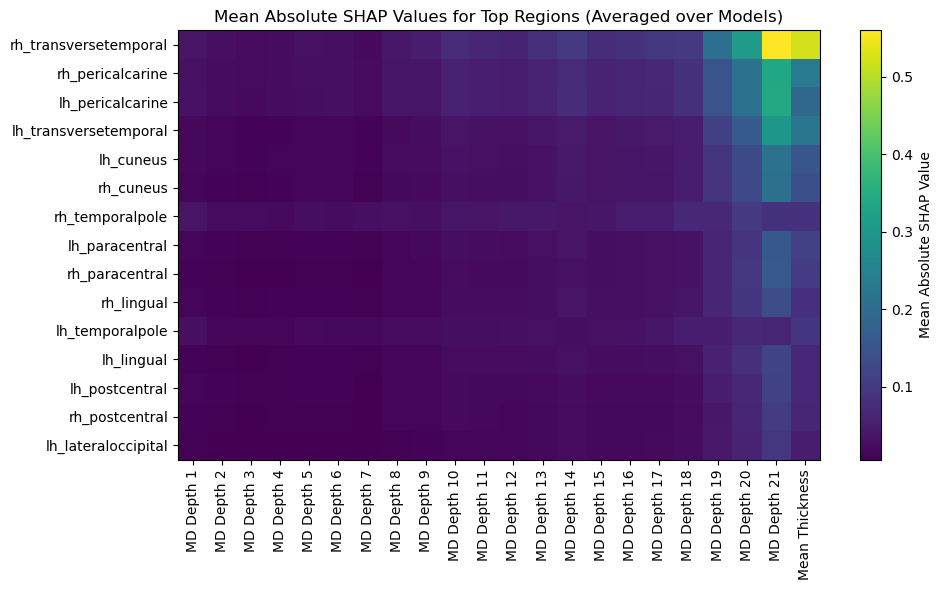

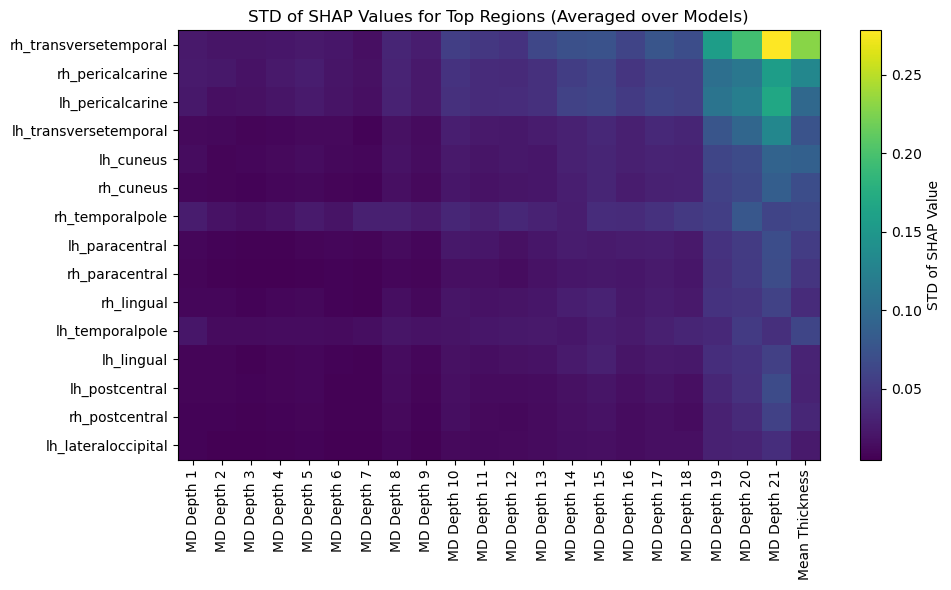

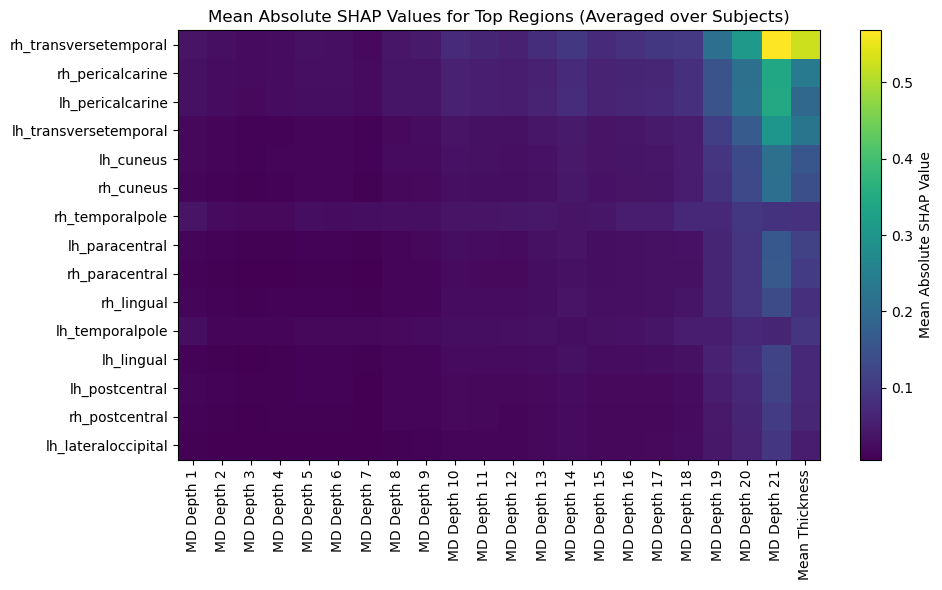

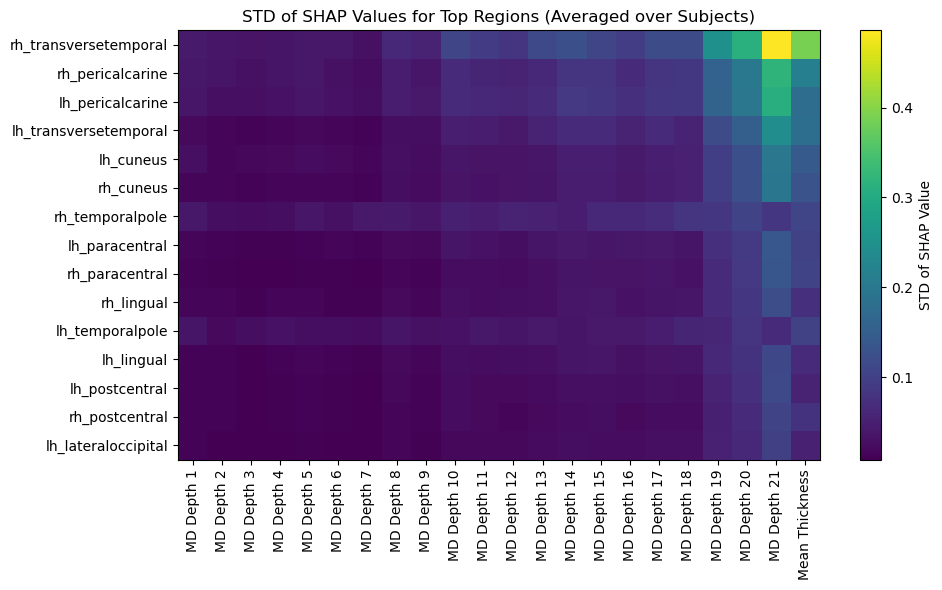

In [13]:
# Top 15 regions
md_top_regions = mean_abs_md_shap_values_per_model.mean(axis=1).argsort()[-15:][::-1]
md_top_regions = [region_keys[i] for i in md_top_regions]

# Plot the heatmap of mean absolute SHAP values for the top regions and features per model
plt.figure(figsize=(10, 6))
plt.imshow(mean_abs_md_shap_values_per_model[[region_keys.index(region) for region in md_top_regions]], aspect='auto', cmap='viridis')
plt.colorbar(label='Mean Absolute SHAP Value')
plt.xticks(ticks=np.arange(len(MD_FEATURE_NAMES)), labels=MD_FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(md_top_regions)), labels=md_top_regions)
plt.title('Mean Absolute SHAP Values for Top Regions (Averaged over Models)')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "md_mean_abs_shap_top_regions_per_model_heatmap.png"))
plt.show()

# Plot the heatmap of std SHAP values for the top regions and features per model
plt.figure(figsize=(10, 6))
plt.imshow(mean_std_md_shap_values_per_model[[region_keys.index(region) for region in md_top_regions]], aspect='auto', cmap='viridis')
plt.colorbar(label='STD of SHAP Value')
plt.xticks(ticks=np.arange(len(MD_FEATURE_NAMES)), labels=MD_FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(md_top_regions)), labels=md_top_regions)
plt.title('STD of SHAP Values for Top Regions (Averaged over Models)')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "md_std_shap_top_regions_per_model_heatmap.png"))
plt.show()

# Plot the heatmap of mean absolute SHAP values for the top regions and features per subject
plt.figure(figsize=(10, 6))
plt.imshow(mean_abs_md_shap_values_per_subject[[region_keys.index(region) for region in md_top_regions]], aspect='auto', cmap='viridis')
plt.colorbar(label='Mean Absolute SHAP Value')
plt.xticks(ticks=np.arange(len(MD_FEATURE_NAMES)), labels=MD_FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(md_top_regions)), labels=md_top_regions)
plt.title('Mean Absolute SHAP Values for Top Regions (Averaged over Subjects)')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "md_mean_abs_shap_top_regions_per_subject_heatmap.png"))
plt.show()

# Plot the heatmap of std SHAP values for the top regions and features per subject
plt.figure(figsize=(10, 6))
plt.imshow(mean_std_md_shap_values_per_subject[[region_keys.index(region) for region in md_top_regions]], aspect='auto', cmap='viridis')
plt.colorbar(label='STD of SHAP Value')
plt.xticks(ticks=np.arange(len(MD_FEATURE_NAMES)), labels=MD_FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(md_top_regions)), labels=md_top_regions)
plt.title('STD of SHAP Values for Top Regions (Averaged over Subjects)')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "md_std_shap_top_regions_per_subject_heatmap.png"))
plt.show()


## Plot SHAP of TOP QSM

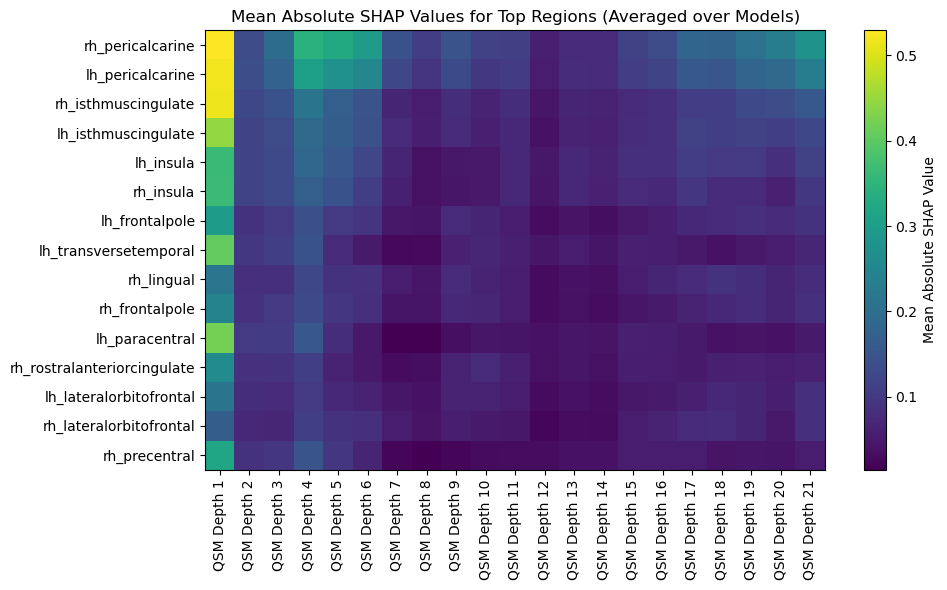

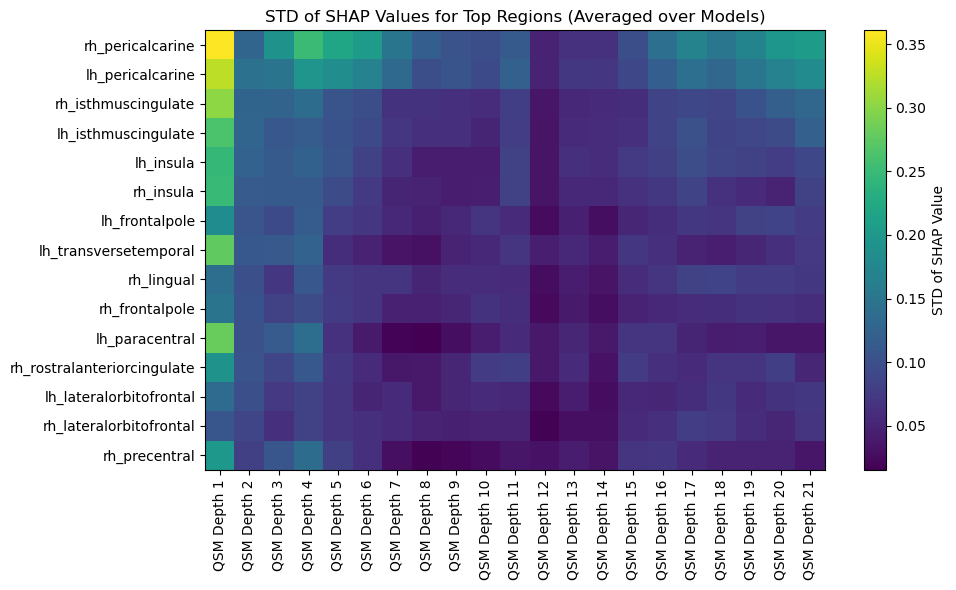

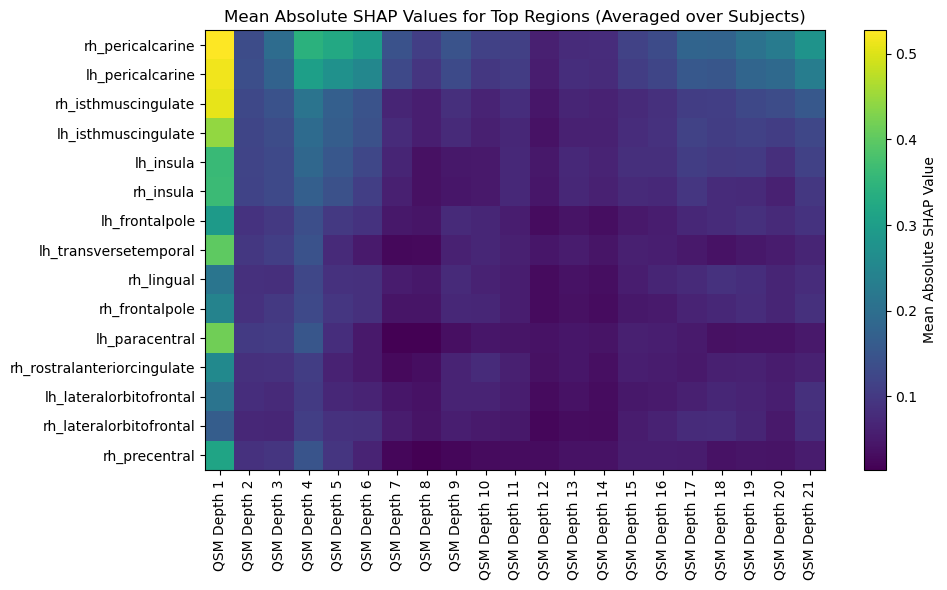

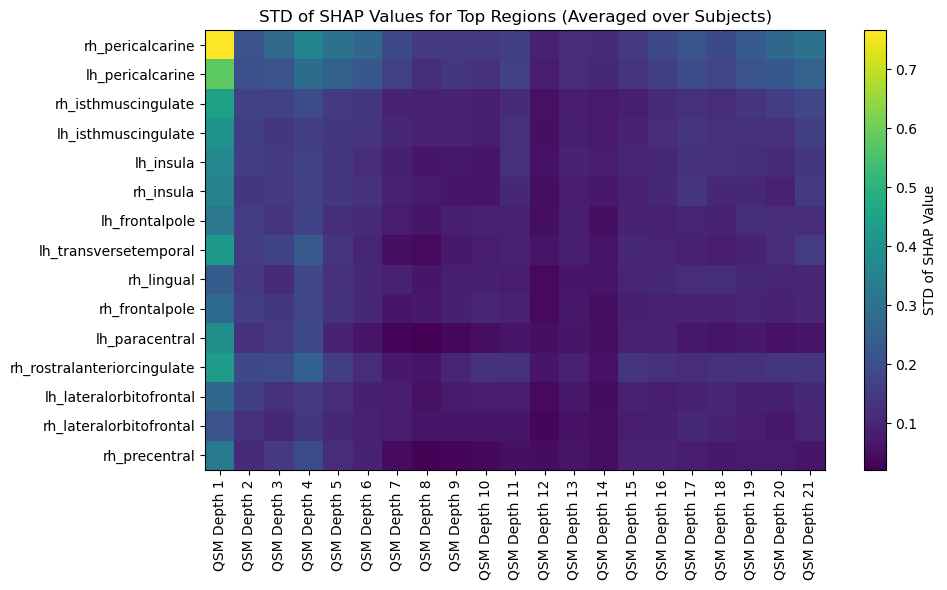

In [14]:
# Top 15 regions
qsm_top_regions = mean_abs_qsm_shap_values_per_model.mean(axis=1).argsort()[-15:][::-1]
qsm_top_regions = [region_keys[i] for i in qsm_top_regions]

# Plot the heatmap of mean absolute SHAP values for the top regions and features per model
plt.figure(figsize=(10, 6))
plt.imshow(mean_abs_qsm_shap_values_per_model[[region_keys.index(region) for region in qsm_top_regions]], aspect='auto', cmap='viridis')
plt.colorbar(label='Mean Absolute SHAP Value')
plt.xticks(ticks=np.arange(len(QSM_FEATURE_NAMES)), labels=QSM_FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(qsm_top_regions)), labels=qsm_top_regions)
plt.title('Mean Absolute SHAP Values for Top Regions (Averaged over Models)')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "qsm_mean_abs_shap_top_regions_per_model_heatmap.png"))
plt.show()

# Plot the heatmap of std SHAP values for the top regions and features per model
plt.figure(figsize=(10, 6))
plt.imshow(mean_std_qsm_shap_values_per_model[[region_keys.index(region) for region in qsm_top_regions]], aspect='auto', cmap='viridis')
plt.colorbar(label='STD of SHAP Value')
plt.xticks(ticks=np.arange(len(QSM_FEATURE_NAMES)), labels=QSM_FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(qsm_top_regions)), labels=qsm_top_regions)
plt.title('STD of SHAP Values for Top Regions (Averaged over Models)')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "qsm_std_shap_top_regions_per_model_heatmap.png"))
plt.show()

# Plot the heatmap of mean absolute SHAP values for the top regions and features per subject
plt.figure(figsize=(10, 6))
plt.imshow(mean_abs_qsm_shap_values_per_subject[[region_keys.index(region) for region in qsm_top_regions]], aspect='auto', cmap='viridis')
plt.colorbar(label='Mean Absolute SHAP Value')
plt.xticks(ticks=np.arange(len(QSM_FEATURE_NAMES)), labels=QSM_FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(qsm_top_regions)), labels=qsm_top_regions)
plt.title('Mean Absolute SHAP Values for Top Regions (Averaged over Subjects)')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "qsm_mean_abs_shap_top_regions_per_subject_heatmap.png"))
plt.show()

# Plot the heatmap of std SHAP values for the top regions and features per subject
plt.figure(figsize=(10, 6))
plt.imshow(mean_std_qsm_shap_values_per_subject[[region_keys.index(region) for region in qsm_top_regions]], aspect='auto', cmap='viridis')
plt.colorbar(label='STD of SHAP Value')
plt.xticks(ticks=np.arange(len(QSM_FEATURE_NAMES)), labels=QSM_FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(qsm_top_regions)), labels=qsm_top_regions)
plt.title('STD of SHAP Values for Top Regions (Averaged over Subjects)')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "qsm_std_shap_top_regions_per_subject_heatmap.png"))
plt.show()


## Plot SHAP of Total Features

In [15]:
# Concatenate MD and QSM SHAP values to find overall top regions
combined_mean_abs_shap_values_per_model = np.hstack((mean_abs_md_shap_values_per_model, mean_abs_qsm_shap_values_per_model))
overall_top_regions = combined_mean_abs_shap_values_per_model.mean(axis=1).argsort()[-15:][::-1]
overall_top_regions = [region_keys[i] for i in overall_top_regions]
print("Overall Top Regions:", overall_top_regions)

Overall Top Regions: ['rh_pericalcarine', 'lh_pericalcarine', 'rh_transversetemporal', 'lh_transversetemporal', 'rh_isthmuscingulate', 'lh_isthmuscingulate', 'rh_lingual', 'lh_insula', 'lh_paracentral', 'rh_insula', 'rh_paracentral', 'lh_lingual', 'lh_frontalpole', 'rh_frontalpole', 'rh_precentral']


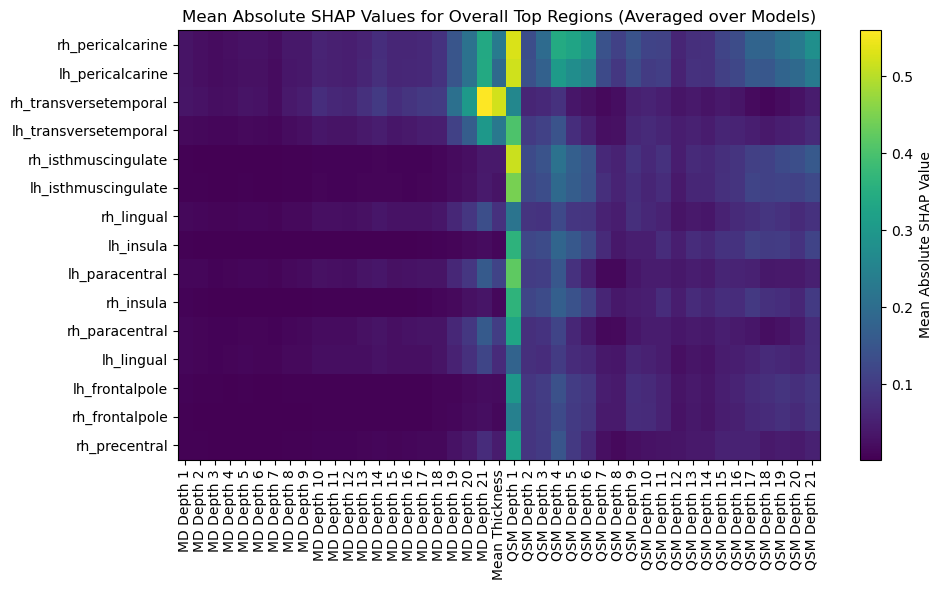

In [16]:
# Plot the overall SHAP
plt.figure(figsize=(10, 6))
plt.imshow(combined_mean_abs_shap_values_per_model[[region_keys.index(region) for region in overall_top_regions]], aspect='auto', cmap='viridis')
plt.colorbar(label='Mean Absolute SHAP Value')
plt.xticks(ticks=np.arange(len(MD_FEATURE_NAMES) + len(QSM_FEATURE_NAMES)), labels=MD_FEATURE_NAMES + QSM_FEATURE_NAMES, rotation=90)
plt.yticks(ticks=np.arange(len(overall_top_regions)), labels=overall_top_regions)
plt.title('Mean Absolute SHAP Values for Overall Top Regions (Averaged over Models)')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "overall_mean_abs_shap_top_regions_per_model_heatmap.png"))
plt.show()
